In [8]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from numpy import load
from tensorflow.python.ops.gen_dataset_ops import TensorDataset

# Wczytanie plików

In [9]:
data = load('Data/synapsemnist3d.npz')
lst = data.files
print(f"Pliki {lst}")

Pliki ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


In [10]:
data['train_images'].shape

(1230, 28, 28, 28)

In [11]:
train_images = data['train_images']
train_labels = data['train_labels']
val_images = data['val_images']
val_labels = data['val_labels']
test_images = data['test_images']
test_labels = data['test_labels']

In [12]:
train_images

array([[[[220,  59, 101, ..., 199,  23, 193],
         [229, 223,  38, ...,  21, 159, 142],
         [241, 160,  28, ...,  13, 156, 133],
         ...,
         [ 37,  23,  29, ...,  27,  42,  81],
         [ 12,  35,  32, ...,  37, 164,  74],
         [ 17,  13,  26, ...,  51,  92,  47]],

        [[187, 193,  95, ...,  79,  61,  70],
         [ 65, 161,  25, ...,  27, 220, 144],
         [ 78, 192,  73, ...,  37, 205, 173],
         ...,
         [ 17,  20,  34, ...,  57,  45, 135],
         [ 42,  51,  25, ..., 184, 122, 193],
         [ 50,  36,  40, ..., 147, 139, 173]],

        [[185, 156, 154, ...,  15,  78,  93],
         [ 89, 136,  84, ...,  63, 156, 143],
         [ 66, 109, 124, ..., 125, 214,  98],
         ...,
         [ 43,  29,  16, ...,  31,  41, 143],
         [ 34,  24,  21, ..., 149, 229, 139],
         [124,  31,  20, ..., 162, 159, 171]],

        ...,

        [[101,  75,  95, ...,  66,  75,  52],
         [127, 180, 129, ..., 172, 122,  71],
         [154, 179

In [13]:
train_labels

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(1230, 1), dtype=uint8)

Text(0.5, 1.0, 'Klasy')

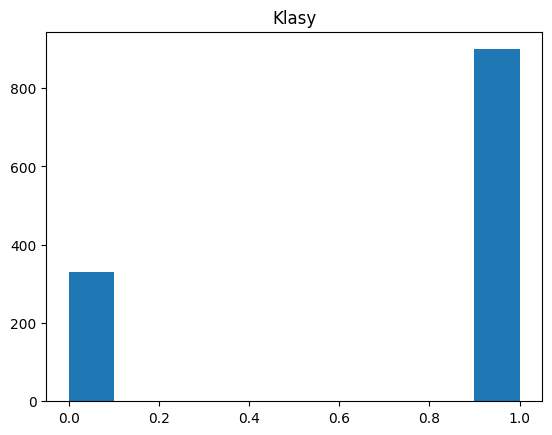

In [45]:
plt.hist(train_labels)
plt.title("Klasy")

# Wyświetlenie przykładowego obrazu

In [14]:
example_image = train_images[0]
example_label = train_labels[0]
example_image

array([[[220,  59, 101, ..., 199,  23, 193],
        [229, 223,  38, ...,  21, 159, 142],
        [241, 160,  28, ...,  13, 156, 133],
        ...,
        [ 37,  23,  29, ...,  27,  42,  81],
        [ 12,  35,  32, ...,  37, 164,  74],
        [ 17,  13,  26, ...,  51,  92,  47]],

       [[187, 193,  95, ...,  79,  61,  70],
        [ 65, 161,  25, ...,  27, 220, 144],
        [ 78, 192,  73, ...,  37, 205, 173],
        ...,
        [ 17,  20,  34, ...,  57,  45, 135],
        [ 42,  51,  25, ..., 184, 122, 193],
        [ 50,  36,  40, ..., 147, 139, 173]],

       [[185, 156, 154, ...,  15,  78,  93],
        [ 89, 136,  84, ...,  63, 156, 143],
        [ 66, 109, 124, ..., 125, 214,  98],
        ...,
        [ 43,  29,  16, ...,  31,  41, 143],
        [ 34,  24,  21, ..., 149, 229, 139],
        [124,  31,  20, ..., 162, 159, 171]],

       ...,

       [[101,  75,  95, ...,  66,  75,  52],
        [127, 180, 129, ..., 172, 122,  71],
        [154, 179, 156, ..., 252, 221, 199

## Wszystkie warstwy

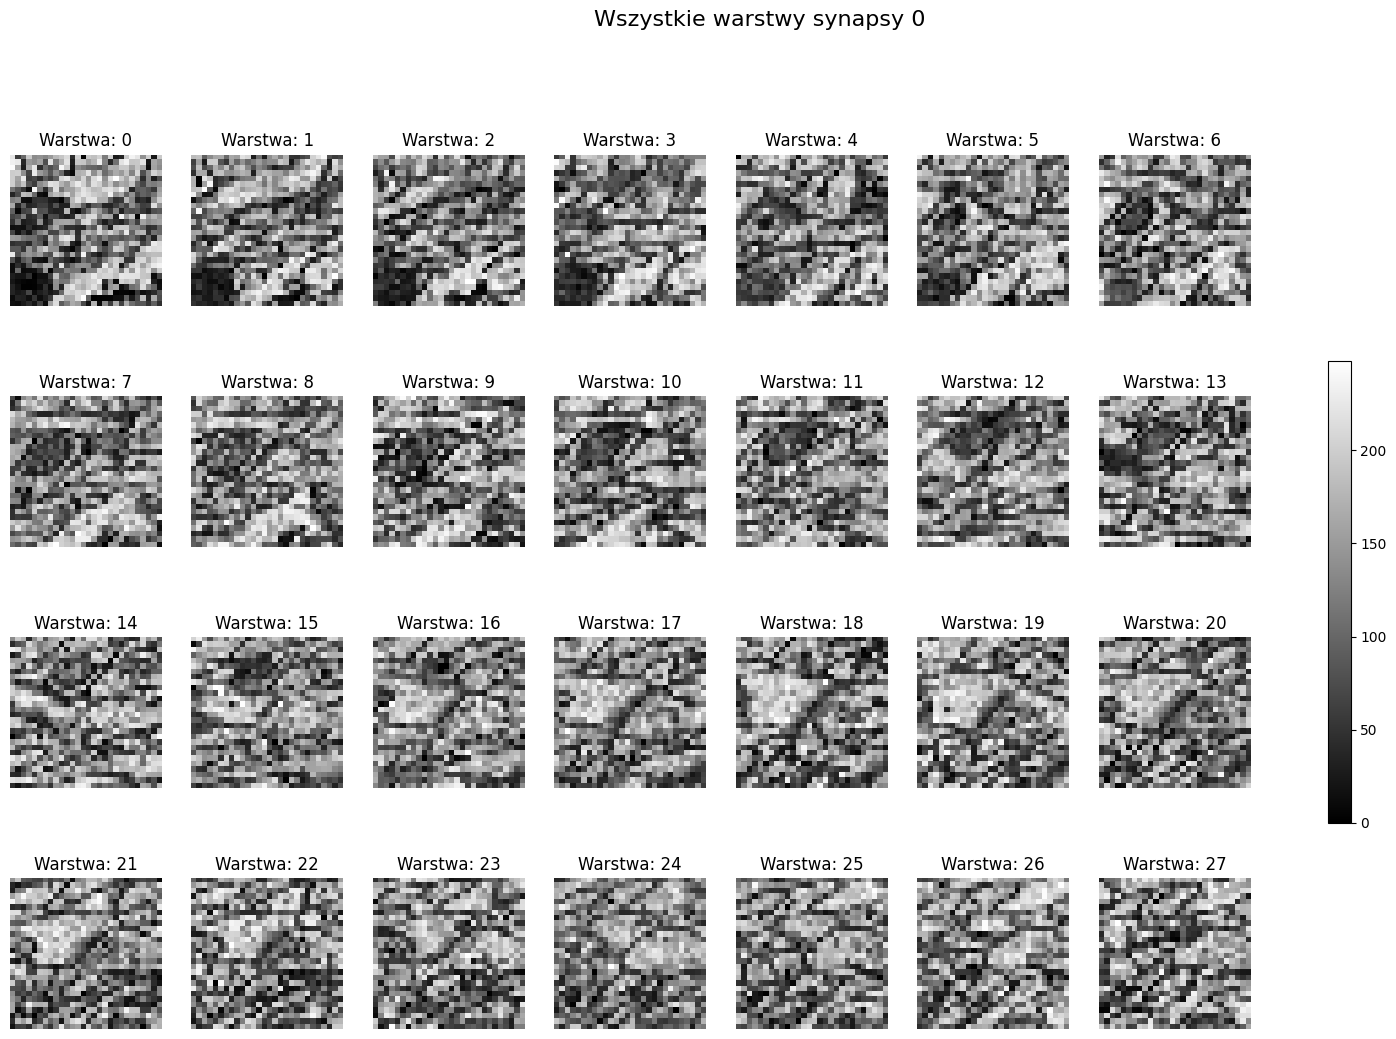

In [23]:
# jest 28 warstw więc robimy subploty
fig, axes = plt.subplots(4, 7, figsize=(20,12))

axes = axes.flatten()

for id in range(28):
    ax = axes[id]
    im = ax.imshow(example_image[id, :, :], cmap='gray')
    ax.set_title(f"Warstwa: {id}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
plt.suptitle(f"Wszystkie warstwy synapsy {0}", fontsize=16)
plt.show()

## Histogramy

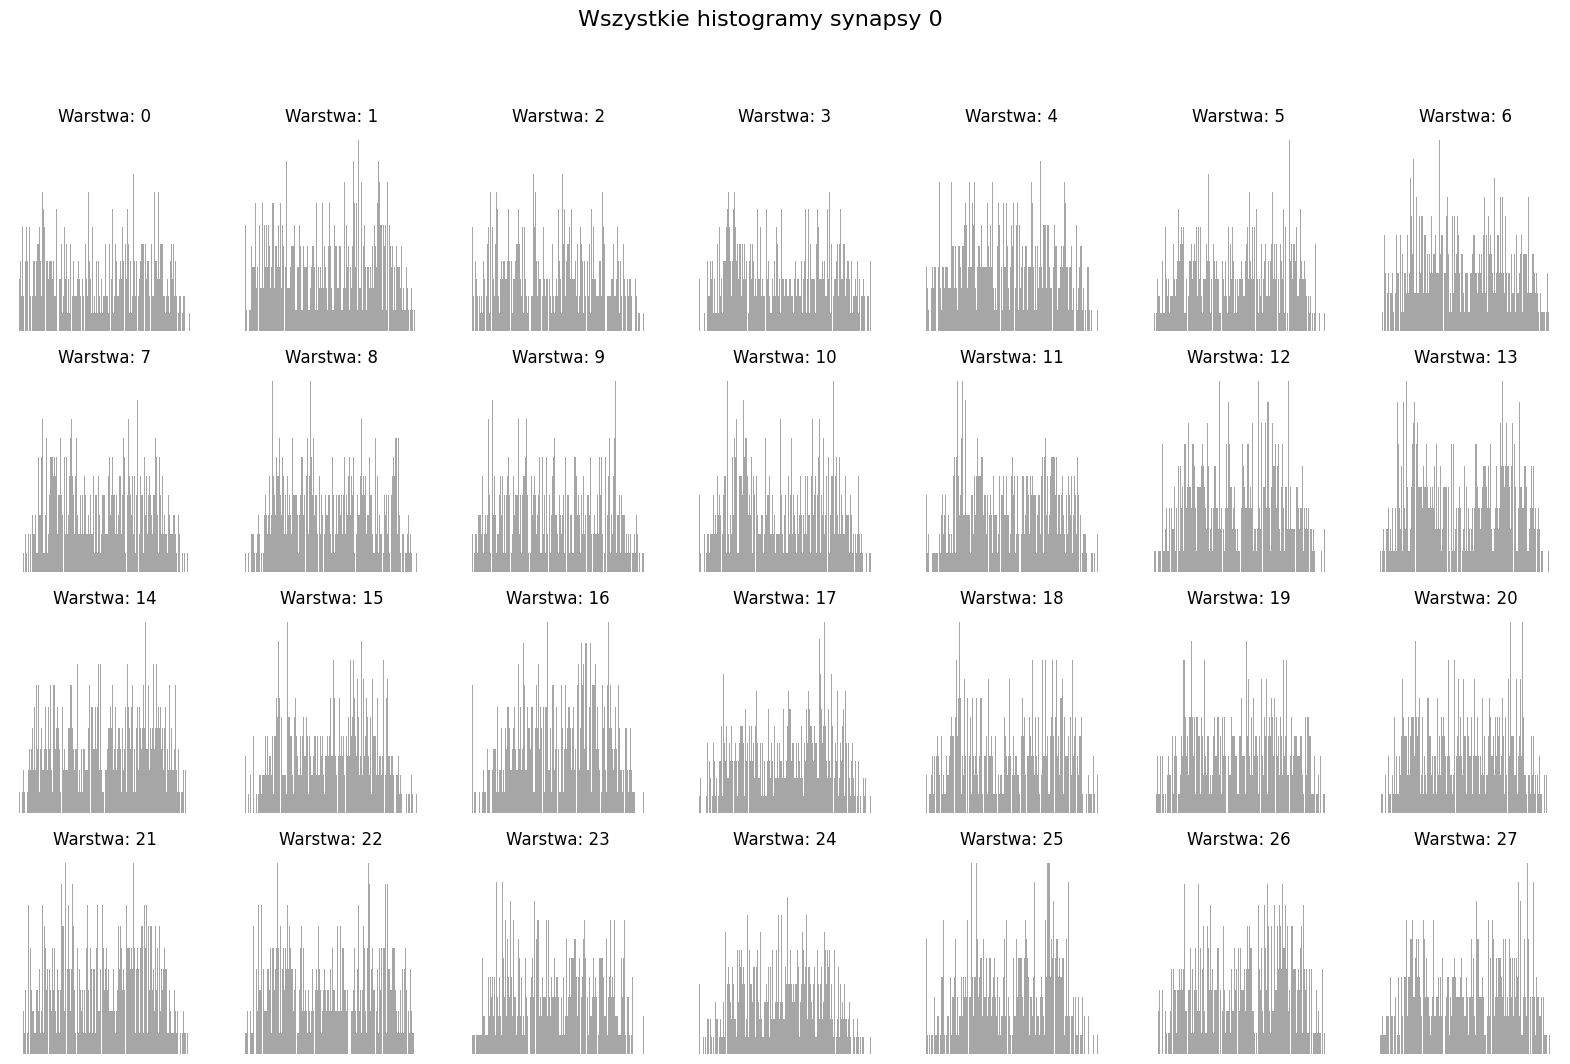

In [31]:
# jest 28 warstw więc robimy subploty
fig, axes = plt.subplots(4, 7, figsize=(20,12))

axes = axes.flatten()

for id in range(28):
    ax = axes[id]
    im = ax.hist(example_image[id, :, :].flatten(), bins=256, color='gray', alpha=0.7)
    ax.set_title(f"Warstwa: {id}")
    ax.axis("off")

plt.suptitle(f"Wszystkie histogramy synapsy {0}", fontsize=16)
plt.show()

# Zadanie
Niezbyt wiem co można tutaj odkrywać póki co xD.
Mózg małpy każe zrobić mi model do klasyfikacji więc zrobię to. Lets go ! Skorzystam z pytorcha wszelkie użyte pakiety będą w requirements. Cuda jakby co 12.8

## Wczytanie do dataloaderów

In [46]:
import tensorflow as tf
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from PIL import Image
import torchvision.transforms as transforms
from sklearn.dummy import DummyClassifier
import torch.nn.functional as F

In [39]:
X_train = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_images, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(val_labels, dtype=torch.long)

X_test = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_labels, dtype=torch.long)


BATCH_SIZE = 32
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [40]:
train_loader

## Sieć neuronowa

In [55]:
class CNN_3D(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN_3D, self).__init__()

        self.conv1 = nn.Conv3d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 =  nn.Conv3d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 7 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.droput = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.droput(x)
        x = self.fc2(x)

        return x

model = CNN_3D(num_classes=2)

## Trening

In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        labels = labels.squeeze().long()
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            labels = labels.squeeze().long()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (train_correct / total_train) * 100
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_correct / total_val) * 100

    print(f"Epoka [{epoch+1}/{num_epochs}]")
    print(f"Trening -> Strata: {epoch_train_loss:.4f}, Dokładność: {epoch_train_acc:.2f}%")
    print(f"Walidacja   -> Strata: {epoch_val_loss:.4f}, Dokładność: {epoch_val_acc:.2f}%")
    print("-" * 30)

Epoka [1/20]
Trening -> Strata: 0.1540, Dokładność: 93.98%
Walidacja   -> Strata: 3.1392, Dokładność: 58.19%
------------------------------
Epoka [2/20]
Trening -> Strata: 0.1410, Dokładność: 95.12%
Walidacja   -> Strata: 3.2082, Dokładność: 66.10%
------------------------------
Epoka [3/20]
Trening -> Strata: 0.1133, Dokładność: 95.12%
Walidacja   -> Strata: 3.3954, Dokładność: 62.71%
------------------------------
Epoka [4/20]
Trening -> Strata: 0.0805, Dokładność: 97.07%
Walidacja   -> Strata: 3.7916, Dokładność: 65.54%
------------------------------
Epoka [5/20]
Trening -> Strata: 0.1830, Dokładność: 92.93%
Walidacja   -> Strata: 2.4546, Dokładność: 64.97%
------------------------------
Epoka [6/20]
Trening -> Strata: 0.1106, Dokładność: 96.02%
Walidacja   -> Strata: 5.3384, Dokładność: 67.80%
------------------------------
Epoka [7/20]
Trening -> Strata: 0.1920, Dokładność: 92.68%
Walidacja   -> Strata: 3.4815, Dokładność: 64.97%
------------------------------
Epoka [8/20]
Trening

## Test

In [70]:
all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.view(-1).numpy())

Dokładność: 66.48%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.22      0.09      0.13        95
           1       0.72      0.88      0.79       257

    accuracy                           0.66       352
   macro avg       0.47      0.49      0.46       352
weighted avg       0.59      0.66      0.61       352



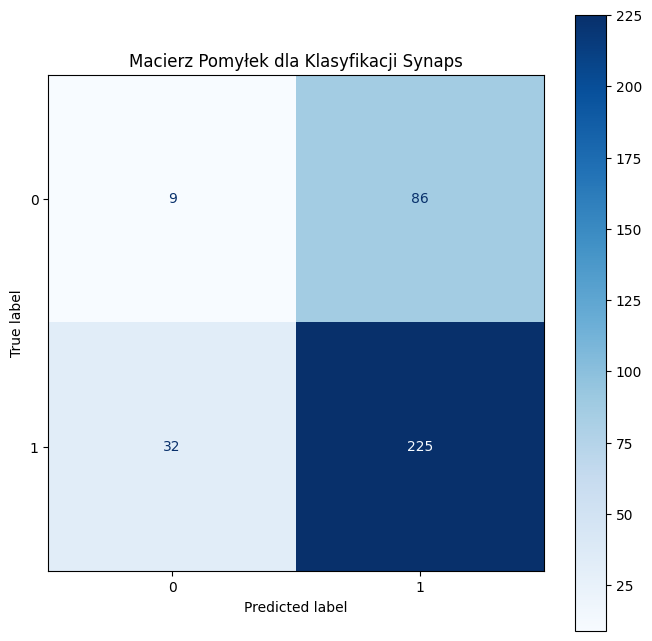

In [71]:
acc = accuracy_score(all_true, all_preds)
print(f"Dokładność: {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(all_true, all_preds, target_names=['0', '1']))

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Macierz Pomyłek dla Klasyfikacji Synaps')
plt.show()